In [1]:
import pandas as pd
raw=pd.DataFrame(pd.read_csv("C:/Users/Yuli/Documents/PSY/PSY 371F/FinalProject/2025_FinalProject_-00101010-/mobile_game_inapp_purchases.csv"))
print(f"raw data contains {len(raw)} rows")
raw=raw.dropna(how='any')
print(f"raw data contains {len(raw)} rows")
print(raw['GameGenre'].unique())
raw_temp=raw.copy()
raw_temp['GameGenre'].replace(['Battle Royale', 'Action RPG', 'Fighting', 'Racing', 'Simulation', 'MMORPG',
 'Role Playing', 'Sports', 'Card', 'Sandbox', 'Puzzle', 'Strategy', 'Casual',
 'Adventure', 'MOBA'], [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14], inplace=True)
raw_temp=raw_temp.rename(columns={'GameGenre':'target'})
raw_temp['GameGenre']=raw['GameGenre']
raw_temp.columns

raw data contains 3024 rows
raw data contains 2612 rows
['Battle Royale' 'Action RPG' 'Fighting' 'Racing' 'Simulation' 'MMORPG'
 'Role Playing' 'Sports' 'Card' 'Sandbox' 'Puzzle' 'Strategy' 'Casual'
 'Adventure' 'MOBA']


C:\Users\Yuli\AppData\Local\Temp\ipykernel_7628\253360450.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_temp['GameGenre'].replace(['Battle Royale', 'Action RPG', 'Fighting', 'Racing', 'Simulation', 'MMORPG',
C:\Users\Yuli\AppData\Local\Temp\ipykernel_7628\253360450.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_si

Index(['UserID', 'Age', 'Gender', 'Country', 'Device', 'target',
       'SessionCount', 'AverageSessionLength', 'SpendingSegment',
       'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod',
       'LastPurchaseDate', 'GameGenre'],
      dtype='object')

In [34]:
# code for knn classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
import math
y,features=raw_temp['target'],['SessionCount', 'AverageSessionLength','InAppPurchaseAmount','Age']
acc_score, final_model, final_y_pred, final_y_test, final_k, final_f1, final_f2,final_X_test=0,0,0,0,0,0,0,0

for f1 in features:
    for f2 in features:
        if f1!=f2:
            for k in range(1, int(math.sqrt(2612))):
                knn=KNeighborsClassifier(n_neighbors=k)
                X=list(zip(raw_temp[f1],raw_temp[f2]))
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
                knn.fit(X_train, y_train)
                y_pred=knn.predict(X_test)
                if accuracy_score(y_test, y_pred)>acc_score:
                    acc_score, final_model, final_y_pred, final_y_test, final_k, final_f1, final_f2=accuracy_score(y_test, y_pred), knn, y_pred, y_test, k, f1, f2
                    final_X_test=X_test
if acc_score<0.7:
    print(accuracy_score(final_y_test, final_y_pred))
    print("Classification to classify 15 game genre failed")

0.09369024856596558
Classification to classify 15 game genre failed


In [3]:
for k in range(1, int(math.sqrt(2612))):
                knn=KNeighborsClassifier(n_neighbors=k)
                X=list(zip(raw_temp['SessionCount'],raw_temp['AverageSessionLength'],raw_temp['InAppPurchaseAmount'],raw_temp['Age']))
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
                knn.fit(X_train, y_train)
                y_pred=knn.predict(X_test)
                if accuracy_score(y_test, y_pred)>acc_score:
                    acc_score, final_model, final_y_pred, final_y_test, final_k, final_f1, final_f2=accuracy_score(y_test, y_pred), knn, y_pred, y_test, k, f1, f2
print(acc_score)


0.09369024856596558


In [4]:
import matplotlib.pyplot as plt

In [46]:
raw=pd.DataFrame(pd.read_csv("C:/Users/Yuli/Documents/PSY/PSY 371F/FinalProject/2025_FinalProject_-00101010-/mobile_game_inapp_purchases.csv"))
raw=raw.dropna(how='any')
raw_temp=raw.copy()
raw_temp['GameGenre'].replace(['Battle Royale', 'Action RPG', 'Fighting', 'Racing', 'Simulation', 'MMORPG', 'Role Playing', 'Sports', 'Card', 'Sandbox','Puzzle', 'Strategy', 'Casual', 'Adventure', 'MOBA'], [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14], inplace=True)
raw_temp=raw_temp.rename(columns={'GameGenre':'target'})
raw_temp['GameGenre']=raw['GameGenre']
raw_temp.columns
pr=preprocessing.LabelEncoder()
y,features=raw_temp['target'],['SessionCount', 'AverageSessionLength','InAppPurchaseAmount']
acc_score, final_model, final_y_pred, final_y_test, final_k, final_f1, final_f2=0,0,0,0,0,0,0

for f1 in features:
    for f2 in features:
        if f1!=f2:
            for k in range(1, int(math.sqrt(2612))):
                knn=KNeighborsClassifier(n_neighbors=k)
                X=list(zip(raw_temp[f1],raw_temp[f2]))
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
                knn.fit(X_train, y_train)
                y_pred=knn.predict(X_test)
                if accuracy_score(y_test, y_pred)>acc_score:
                    acc_score, final_model, final_y_pred, final_y_test, final_k, final_f1, final_f2=accuracy_score(y_test, y_pred), knn, y_pred, y_test, k, f1, f2
if acc_score<0.7:
    print(accuracy_score(final_y_test, final_y_pred))
    print("Classification to classify 15 game genre failed")
else:
    print(f"Success. Continue to graph")
plt.plot

C:\Users\Yuli\AppData\Local\Temp\ipykernel_19012\1160303301.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_temp['GameGenre'].replace(['Battle Royale', 'Action RPG', 'Fighting', 'Racing', 'Simulation', 'MMORPG', 'Role Playing', 'Sports', 'Card', 'Sandbox', 'Puzzle', 'Strategy', 'Casual', 'Adventure', 'MOBA'], [0,0,0,1,2,0,3,1,1,2,1,4,5,3,0], inplace=True)
C:\Users\Yuli\AppData\Local\Temp\ipykernel_19012\1160303301.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future versi

0.3231357552581262
Classification to classify 15 game genre failed


R2 score: 0.004399054515535461, regression model failed, k=9


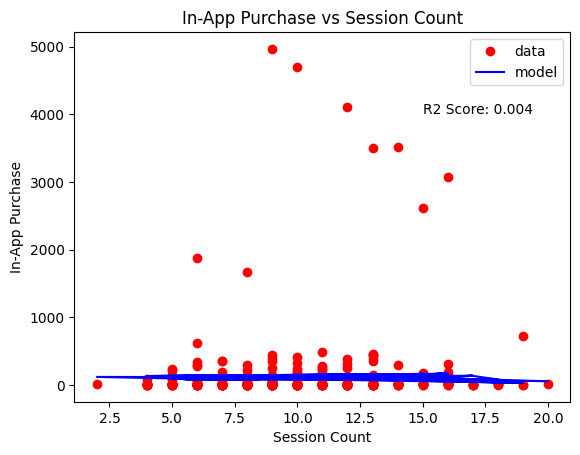

In [25]:
# code for regression
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score 

r2_final, coeffs, f2, f1=0,0, 'InAppPurchaseAmount', 'SessionCount'
for k in range(1,10):
    X_train, X_test, y_train, y_test = train_test_split(raw_temp[f1], raw_temp[f2], test_size=0.2,random_state=42)
    r2=r2_score(y_true=y_test, y_pred=np.polyval(np.polyfit(X_train,y_train,deg=k),X_test))
    if r2>r2_final:
        r2_final, coeffs=r2, np.polyfit(X_train,y_train,deg=k)
if r2_final<0.5:
    print(f"R2 score: {r2_final}, regression model failed, k={k}")
else:
    print(f"Success. Continue to graph")
plt.plot(X_test, y_test, 'ro')
plt.plot(X_test, np.polyval(np.polyfit(X_train,y_train,deg=k),X_test), 'b-')
plt.title('In-App Purchase vs Session Count')
plt.text(15,4000,f'R2 Score: {r2_final:.3f}')
plt.xlabel('Session Count')
plt.ylabel('In-App Purchase')
plt.legend(['data','model'])

R2 score: 0, regression model failed, k=9


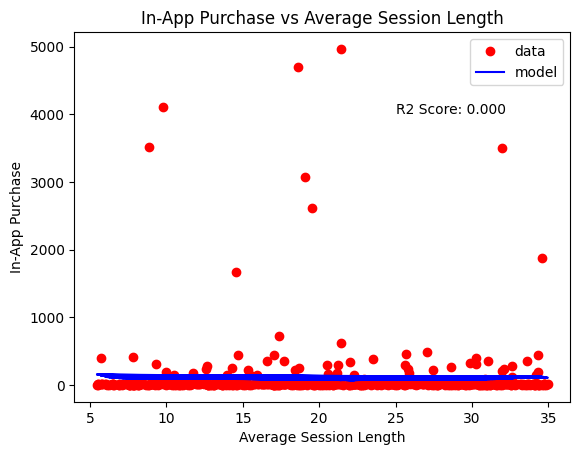

In [28]:
# code for regression

r2_final, coeffs, f2, f1=0,0, 'InAppPurchaseAmount', 'AverageSessionLength'
for k in range(1,10):
    X_train, X_test, y_train, y_test = train_test_split(raw_temp[f1], raw_temp[f2], test_size=0.2,random_state=42)
    r2=r2_score(y_true=y_test, y_pred=np.polyval(np.polyfit(X_train,y_train,deg=k),X_test))
    if r2>r2_final:
        r2_final, coeffs=r2, np.polyfit(X_train,y_train,deg=k)
if r2_final<0.5:
    print(f"R2 score: {r2_final}, regression model failed, k={k}")
else:
    print(f"Success. Continue to graph")
plt.plot(X_test, y_test, 'ro')
plt.plot(X_test, np.polyval(np.polyfit(X_train,y_train,deg=k),X_test), 'b-')
plt.title('In-App Purchase vs Average Session Length')
plt.text(25,4000,f'R2 Score: {r2_final:.3f}')
plt.xlabel('Average Session Length')
plt.ylabel('In-App Purchase')
plt.legend(['data','model'])

R2 score: 0, regression model failed, k=9


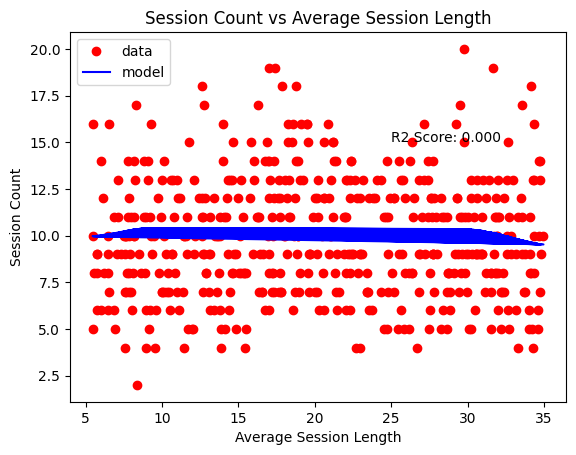

In [30]:
r2_final, coeffs, f2, f1=0,0, 'SessionCount', 'AverageSessionLength'
for k in range(1,10):
    X_train, X_test, y_train, y_test = train_test_split(raw_temp[f1], raw_temp[f2], test_size=0.2,random_state=42)
    r2=r2_score(y_true=y_test, y_pred=np.polyval(np.polyfit(X_train,y_train,deg=k),X_test))
    if r2>r2_final:
        r2_final, coeffs=r2, np.polyfit(X_train,y_train,deg=k)
if r2_final<0.5:
    print(f"R2 score: {r2_final}, regression model failed, k={k}")
else:
    print(f"Success. Continue to graph")
plt.plot(X_test, y_test, 'ro')
plt.plot(X_test, np.polyval(np.polyfit(X_train,y_train,deg=k),X_test), 'b-')
plt.title('Session Count vs Average Session Length')
plt.text(25,15,f'R2 Score: {r2_final:.3f}')
plt.xlabel('Average Session Length')
plt.ylabel('Session Count')
plt.legend(['data','model'])